Importing required libraries

In [52]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

import numpy as np
import pickle
import os


In [4]:
train_df = pd.read_csv('../data/clean_cicids_train.csv')
test_df = pd.read_csv('../data/clean_cicids_test.csv')

In [6]:
train_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Source_day,attack_binary
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,monday_df,0
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,monday_df,0
2,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,monday_df,0
3,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,BENIGN,monday_df,0
4,88,609,7,4,484,414,233,0,69.142857,111.967895,...,0.0,0,0,0.0,0.0,0,0,BENIGN,monday_df,0


In [12]:
train_df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       '

In [16]:
print(train_df.shape, test_df.shape)

(2056891, 60) (514226, 60)


In [14]:
print(f'Training data percentage:{(train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')
print(f'Testing data percentage:{(test_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')

Training data percentage:79.99989887663611
Testing data percentage:20.00010112336389


In [18]:
TARGET_COLUMN = 'attack_binary'
non_feature_cols = ['Label', 'Source_day', 'attack_binary']
FEATURE_COLUMNS = [c for c in train_df.columns if c not in non_feature_cols]

In [20]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

In [22]:
print(len(FEATURE_COLUMNS), "features")
print(y_train.value_counts(normalize=True))

57 features
attack_binary
0    0.821699
1    0.178301
Name: proportion, dtype: float64


In [28]:
print(f"Data loaded and prepared for {len(FEATURE_COLUMNS)} features and target '{TARGET_COLUMN}'.\n")

Data loaded and prepared for 57 features and target 'attack_binary'.



In [30]:
train_df.shape

(2056891, 60)

In [32]:
print(train_df.describe())

       Destination Port  Flow Duration  Total Fwd Packets  \
count      2.056891e+06   2.056891e+06       2.056891e+06   
mean       7.813719e+03   1.907245e+07       1.154559e+01   
std        1.826982e+04   3.721461e+07       8.729697e+02   
min        0.000000e+00  -1.200000e+01       1.000000e+00   
25%        5.300000e+01   2.510000e+02       2.000000e+00   
50%        8.000000e+01   6.725100e+04       2.000000e+00   
75%        4.430000e+02   6.093124e+06       7.000000e+00   
max        6.553400e+04   1.200000e+08       2.197590e+05   

       Total Backward Packets  Total Length of Fwd Packets  \
count            2.056891e+06                 2.056891e+06   
mean             1.307836e+01                 6.817250e+02   
std              1.161649e+03                 1.165613e+04   
min              0.000000e+00                 0.000000e+00   
25%              1.000000e+00                 2.600000e+01   
50%              2.000000e+00                 6.800000e+01   
75%             

In [34]:
print(f'Training data percentage:{(train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')
print(f'Testing data percentage:{(test_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')

Training data percentage:79.99989887663611
Testing data percentage:20.00010112336389


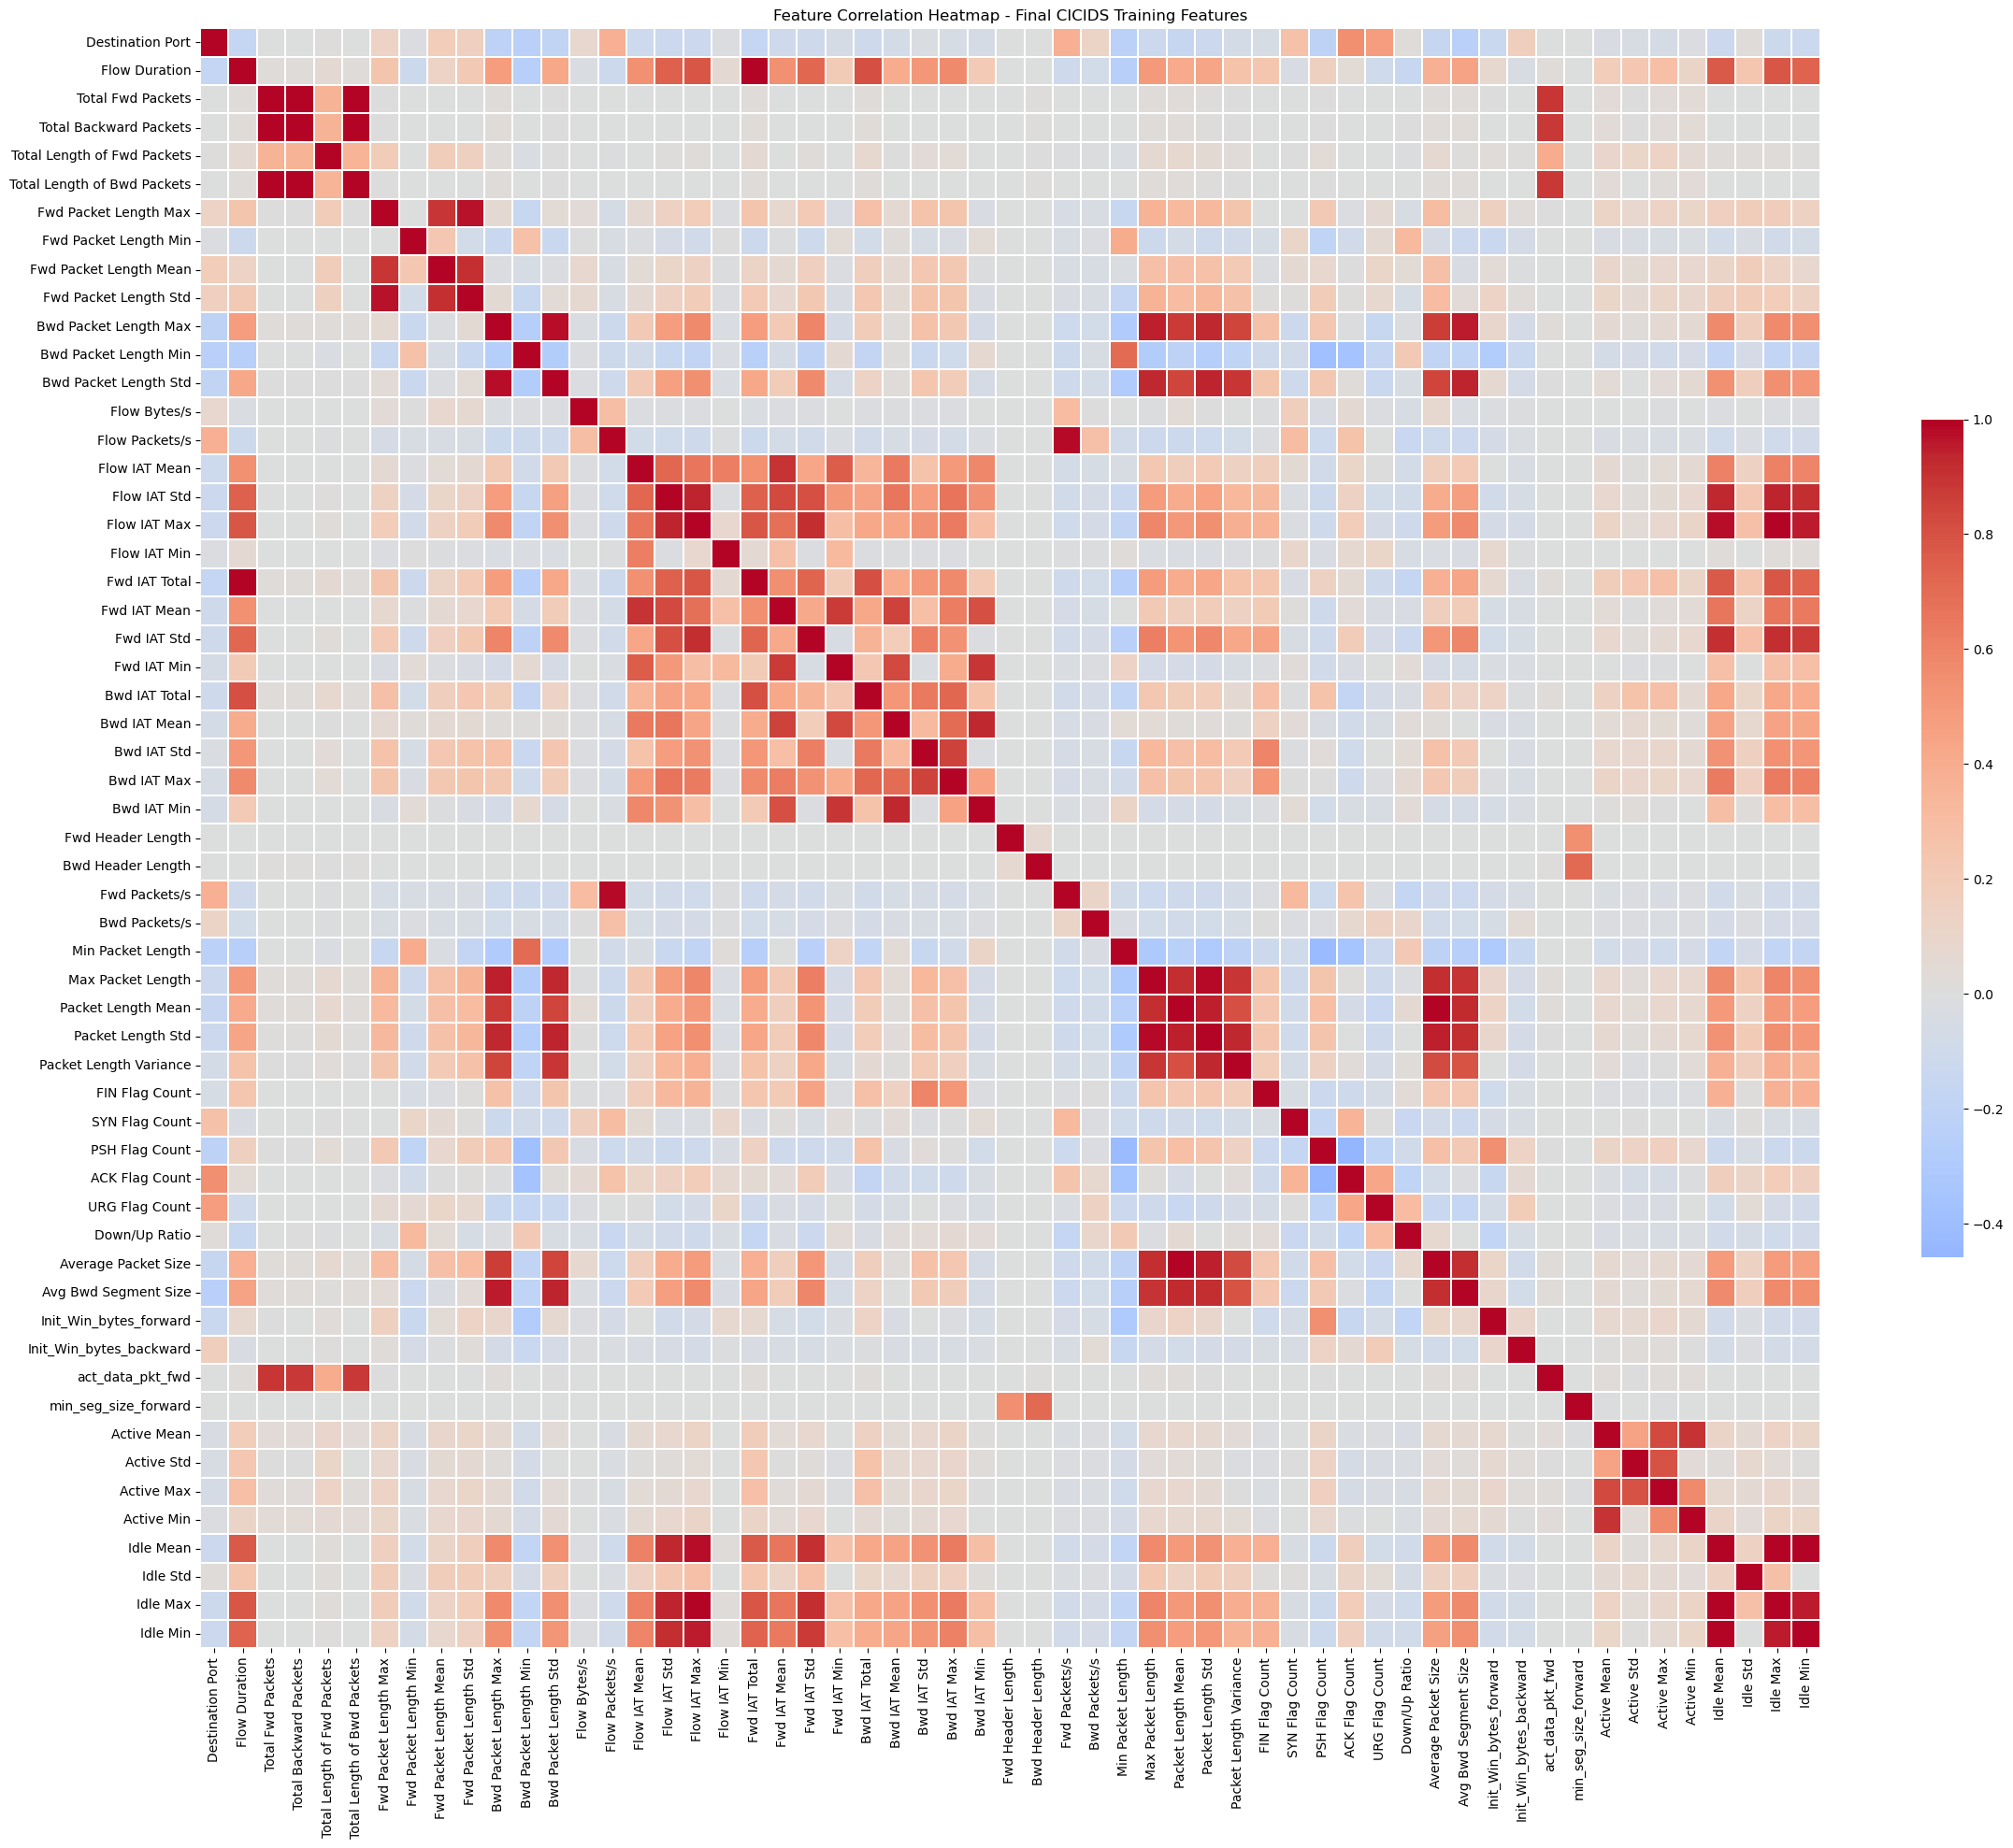

In [38]:
corr_matrix = X_train.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.5})
plt.title('Feature Correlation Heatmap - Final CICIDS Training Features')
plt.tight_layout()
plt.show()

In [40]:
constant_check = [col for col in X_train.columns if X_train[col].nunique() == 1]
print("Still-constant columns:", constant_check)

Still-constant columns: []


In [42]:
def get_high_corr_pairs(corr_matrix, threshold=0.95):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if pd.notna(val) and abs(val) >= threshold:
                pairs.append((cols[i], cols[j], round(val, 3)))
    return pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values(
        'correlation', ascending=False, key=abs)

high_corr = get_high_corr_pairs(corr_matrix, threshold=0.95)
print(high_corr.to_string())

                 feature_1                    feature_2  correlation
0            Flow Duration                Fwd IAT Total        0.999
1        Total Fwd Packets       Total Backward Packets        0.999
12      Packet Length Mean          Average Packet Size        0.998
2        Total Fwd Packets  Total Length of Bwd Packets        0.997
3   Total Backward Packets  Total Length of Bwd Packets        0.995
9             Flow IAT Max                     Idle Max        0.990
13               Idle Mean                     Idle Max        0.990
14               Idle Mean                     Idle Min        0.990
7           Flow Packets/s                Fwd Packets/s        0.985
11       Max Packet Length            Packet Length Std        0.984
5    Bwd Packet Length Max        Bwd Packet Length Std        0.983
8             Flow IAT Max                    Idle Mean        0.980
4    Fwd Packet Length Max        Fwd Packet Length Std        0.970
15                Idle Max        

In [44]:
extra_drops = ['Fwd IAT Total', 'Total Backward Packets', 'Average Packet Size']

# Check impact on target correlation before committing
target_corr = X_train.corrwith(y_train)
for col in extra_drops:
    print(col, target_corr[col])

Fwd IAT Total 0.31527351972784035
Total Backward Packets -0.003458845743997274
Average Packet Size 0.5789120202302295


In [48]:
pairs_to_check = [
    ('Flow Duration', 'Fwd IAT Total'),
    ('Total Fwd Packets', 'Total Backward Packets'),
    ('Packet Length Mean', 'Average Packet Size'),
]

for a, b in pairs_to_check:
    print(f"{a}: {target_corr[a]:.4f}   |   {b}: {target_corr[b]:.4f}")

Flow Duration: 0.3138   |   Fwd IAT Total: 0.3153
Total Fwd Packets: -0.0033   |   Total Backward Packets: -0.0035
Packet Length Mean: 0.5775   |   Average Packet Size: 0.5789


In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.6085045467559205


In [54]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_split=100, min_samples_leaf=50,
        class_weight="balanced", random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=50,
        min_samples_leaf=20, max_features='sqrt',
        class_weight="balanced", n_jobs=-1, random_state=42
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=1200, learning_rate=0.03, num_leaves=64, max_depth=-1,
        reg_alpha=0.2, reg_lambda=0.4, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=40, class_weight="balanced", random_state=42, n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=700, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, gamma=0.2,
        reg_alpha=0.1, reg_lambda=0.5, tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", n_jobs=-1, random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=800, depth=8, learning_rate=0.03, l2_leaf_reg=3,
        loss_function='Logloss', class_weights=[1, 2],
        verbose=False, random_seed=42
    ),
}

In [56]:
results = {}
import time
from datetime import datetime


In [58]:
for name, model in models.items():
    print(f"\n{'='*20} Training {name} {'='*20}")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "confusion_matrix": cm,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "classification_report": rep,
        "y_pred": y_pred,
    }

    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing Accuracy  : {test_acc:.4f}")
    print(f"Precision (Attack): {rep['1']['precision']:.4f}")
    print(f"Recall (Attack)   : {rep['1']['recall']:.4f}")
    print(f"F1 (Attack)       : {rep['1']['f1-score']:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 60)



==================== Training Decision Tree ====================
Training Accuracy : 0.9945
Testing Accuracy  : 0.9922
Precision (Attack): 0.9862
Recall (Attack)   : 0.9449
F1 (Attack)       : 0.9651
Confusion Matrix:
 [[454448    782]
 [  3248  55748]]
------------------------------------------------------------

==================== Training Random Forest ====================
Training Accuracy : 0.9988
Testing Accuracy  : 0.9950
Precision (Attack): 0.9977
Recall (Attack)   : 0.9583
F1 (Attack)       : 0.9776
Confusion Matrix:
 [[455101    129]
 [  2458  56538]]
------------------------------------------------------------

==================== Training LightGBM ====================
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 366745, number of negative: 1690146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.195892 seconds.
You can set `force_row_wise=true` to remove the o

In [62]:
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

for name, model in models.items():
    filename = f"cicids_{name.lower().replace(' ', '_')}.pkl"
    with open(f"{MODEL_DIR}/{filename}", "wb") as f:
        pickle.dump(model, f)
    print(f"Saved -> {filename}")

Saved -> cicids_decision_tree.pkl
Saved -> cicids_random_forest.pkl
Saved -> cicids_lightgbm.pkl
Saved -> cicids_xgboost.pkl
Saved -> cicids_catboost.pkl


In [64]:
xgb_model = models['XGBoost']
xgb_pred = xgb_model.predict(X_test)

check_df = test_df.copy()
check_df['predicted'] = xgb_pred
check_df['correct'] = (check_df['attack_binary'] == check_df['predicted'])

print(check_df[check_df['attack_binary']==1].groupby('Label')['correct'].mean().sort_values())

Label
Heartbleed       0.000000
Bot              0.216931
DoS GoldenEye    0.971143
PortScan         0.998211
SSH-Patator      1.000000
Name: correct, dtype: float64


In [66]:
label_recall = check_df[check_df['attack_binary']==1].groupby('Label').agg(
    total=('correct', 'size'),
    recall=('correct', 'mean')
).sort_values('recall')

print(label_recall)

               total    recall
Label                         
Heartbleed        11  0.000000
Bot              378  0.216931
DoS GoldenEye   6896  0.971143
PortScan       50867  0.998211
SSH-Patator      844  1.000000


In [68]:
print("Train Heartbleed count:", (train_df['Label'] == 'Heartbleed').sum())
print("Test Heartbleed count:", (test_df['Label'] == 'Heartbleed').sum())

Train Heartbleed count: 0
Test Heartbleed count: 11


In [72]:
for label in ['Infiltration', 'Web Attack – Sql Injection', 'Web Attack – XSS']:
    train_count = (train_df['Label'] == label).sum()
    test_count = (test_df['Label'] == label).sum()
    print(f"{label}: train={train_count}, test={test_count}")

Infiltration: train=36, test=0
Web Attack – Sql Injection: train=21, test=0
Web Attack – XSS: train=652, test=0


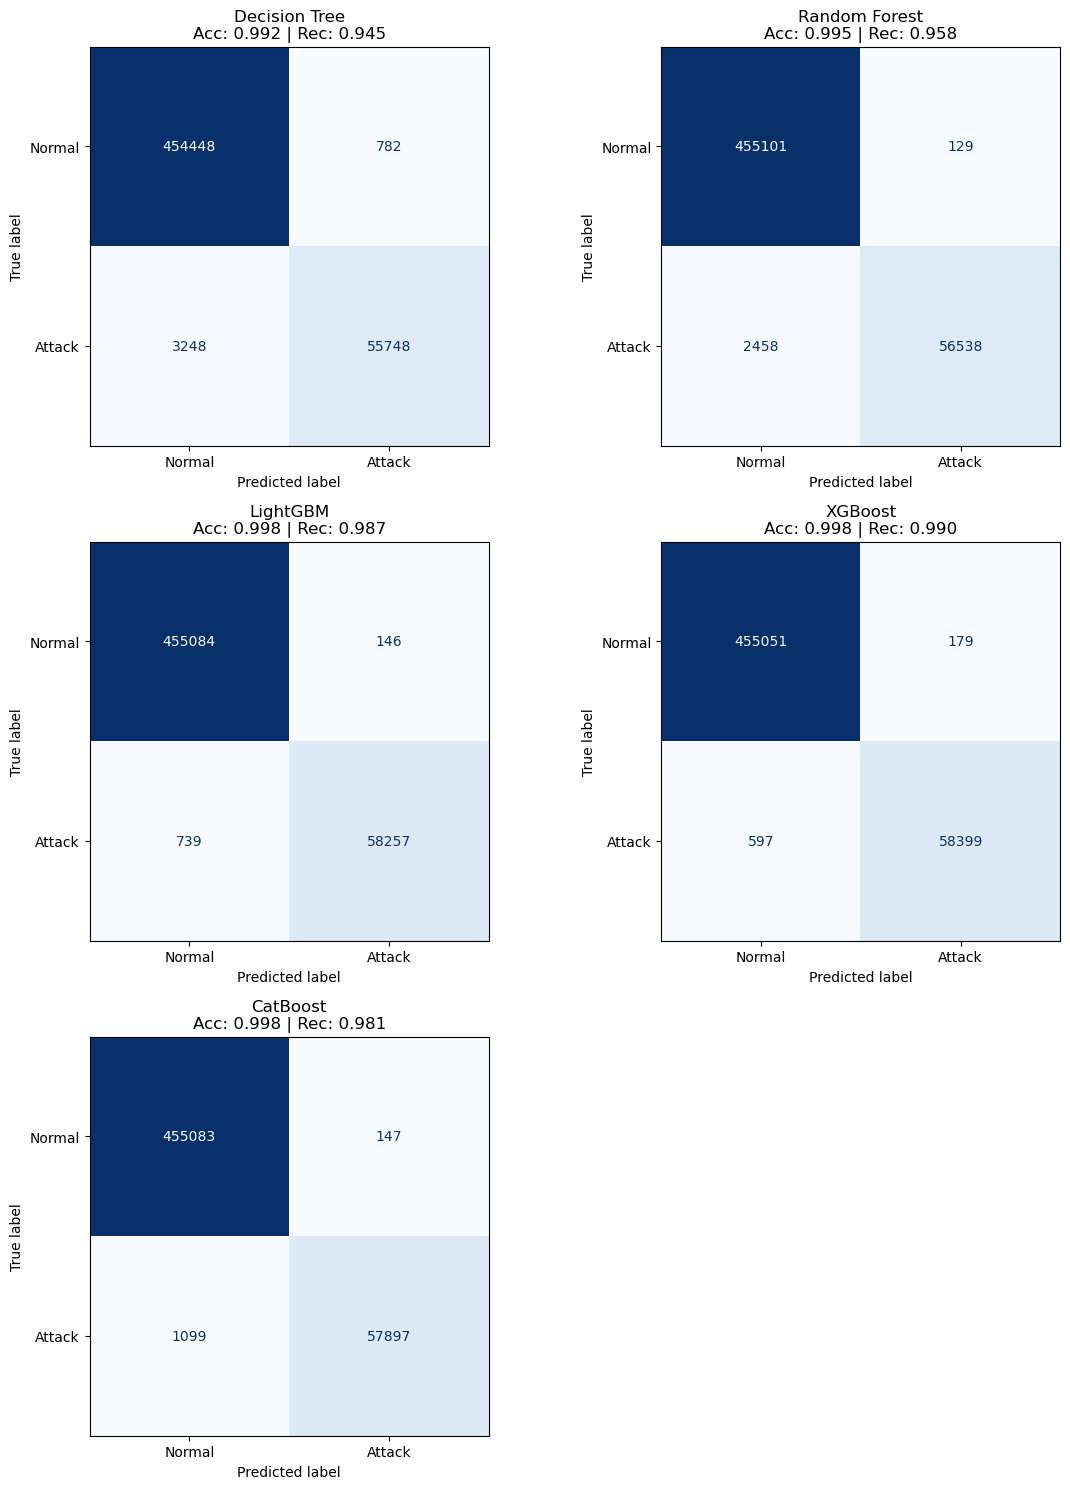

In [60]:
n = len(results)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (name, res) in enumerate(results.items()):
    disp = ConfusionMatrixDisplay(res["confusion_matrix"],
                                  display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    acc = res["test_accuracy"]  # ✅ Changed from "accuracy" to "test_accuracy"
    recall = res["classification_report"]['1']['recall']
    axes[idx].set_title(f"{name}\nAcc: {acc:.3f} | Rec: {recall:.3f}")

# Hide empty subplots
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [74]:
results

{'Decision Tree': {'confusion_matrix': array([[454448,    782],
         [  3248,  55748]], dtype=int64),
  'train_accuracy': 0.9944513345626969,
  'test_accuracy': 0.9921629789236639,
  'classification_report': {'0': {'precision': 0.9929035866601412,
    'recall': 0.9982821870263383,
    'f1-score': 0.9955856224929512,
    'support': 455230.0},
   '1': {'precision': 0.9861666371837963,
    'recall': 0.9449454200284765,
    'f1-score': 0.965116077766044,
    'support': 58996.0},
   'accuracy': 0.9921629789236639,
   'macro avg': {'precision': 0.9895351119219687,
    'recall': 0.9716138035274073,
    'f1-score': 0.9803508501294976,
    'support': 514226.0},
   'weighted avg': {'precision': 0.9921306714996739,
    'recall': 0.9921629789236639,
    'f1-score': 0.9920899197071943,
    'support': 514226.0}},
  'y_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=int64)},
 'Random Forest': {'confusion_matrix': array([[455101,    129],
         [  2458,  56538]], dtype=int64),
  'train_accuracy': 0

In [76]:
data = []
for name, r in results.items():
    rep = r["classification_report"]
    cm = r["confusion_matrix"]
    
    data.append({
        "Model": name,
        "Train_Accuracy": r["train_accuracy"],
        "Test_Accuracy": r["test_accuracy"],
        "Gap": r["train_accuracy"] - r["test_accuracy"],
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "F1_Score": rep["1"]["f1-score"],
        "TN": cm[0,0],
        "FP": cm[0,1],
        "FN": cm[1,0],
        "TP": cm[1,1]
    })

df = pd.DataFrame(data)

# Save as formatted text
with open("../data/summary2.txt", "w", encoding="utf-8") as f:
    f.write(df.to_string(index=False))

print("✓ Saved to summary2.txt (UTF-8 encoded)")

✓ Saved to summary2.txt (UTF-8 encoded)
